In [22]:
import pandas as pd
import numpy as np
import mlflow
import mlflow.sklearn
import matplotlib.pyplot as plt
import json, warnings
warnings.filterwarnings("ignore")
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.model_selection import GridSearchCV
from sklearn.metrics import (
    accuracy_score, f1_score, roc_auc_score,

    precision_score, recall_score,
    classification_report, confusion_matrix,
    ConfusionMatrixDisplay, RocCurveDisplay,
    PrecisionRecallDisplay
)
from imblearn.over_sampling import SMOTE
from imblearn.under_sampling import RandomUnderSampler

In [ ]:
import sys
from pathlib import Path


sys.path.insert(0, str(Path('__file__').resolve().parents[3] / 'src'))

from who_will_viral.models.mlflow_config import setup_mlflow
setup_mlflow()

2026/04/11 22:13:50 INFO mlflow.tracking.fluent: Experiment with name 'youtube-viral' does not exist. Creating a new experiment.


In [25]:
import os
from pathlib import Path
ROOT = Path(os.getcwd())
while not (ROOT / 'src').exists():
    ROOT = ROOT.parent

DATA = ROOT / 'data' / 'youtube'
train = pd.read_csv(DATA / 'scaled_train.csv')
val   = pd.read_csv(DATA / 'scaled_val.csv')
test  = pd.read_csv(DATA / 'scaled_test.csv')

In [26]:
TARGET = 'is_trending'
X_train, y_train = train.drop(columns=[TARGET]), train[TARGET]
X_val,   y_val   = val.drop(columns=[TARGET]),   val[TARGET]
X_test,  y_test  = test.drop(columns=[TARGET]),  test[TARGET]
print('train shape', X_train.shape, ' val shape:', X_val.shape, 'test shape', X_test.shape)
print('\nClass distribution (training data):')
print(y_train.value_counts(normalize=True).round(3))

train shape (108375, 15)  val shape: (36126, 15) test shape (36126, 15)

Class distribution (training data):
is_trending
0    0.822
1    0.178
Name: proportion, dtype: float64


In [27]:
def run_experiment(run_name, model, X_tr, y_tr, X_ev=X_val, y_ev=y_val, params=None, tags=None):

    model.fit(X_tr, y_tr)
    y_pred = model.predict(X_ev)
    # predict probability if supported
    y_prob = model.predict_proba(X_ev)[:, 1] if hasattr(model, 'predict_proba') else None

    metrics = {
        'accuracy' : accuracy_score(y_ev, y_pred),
        'f1'       : f1_score(y_ev, y_pred, zero_division=0, pos_label=1),
        'precision': precision_score(y_ev, y_pred, zero_division=0, pos_label=1),
        'recall'   : recall_score(y_ev, y_pred, zero_division=0, pos_label=1),
        'roc_auc'  : roc_auc_score(y_ev, y_prob) if y_prob is not None else None,
    }

    print(f'  \n{run_name}')
    for k, v in metrics.items():
        if v is not None:
            print(f'  {k}: {v:.4f}')
    print()
    print(classification_report(y_ev, y_pred))

    fig, ax = plt.subplots(figsize=(4, 3))
    ConfusionMatrixDisplay(confusion_matrix(y_ev, y_pred)).plot(ax=ax, colorbar=False)
    ax.set_title(run_name, fontsize=10)
    plt.tight_layout()
    plt.show()

    # track experiments
    with mlflow.start_run(run_name=run_name):
        mlflow.set_tags(tags or {})
        mlflow.log_params(params or {})
        mlflow.log_metrics({k: v for k, v in metrics.items() if v is not None})
        mlflow.sklearn.log_model(model, 'model')
        fig2, ax2 = plt.subplots(figsize=(4, 3))
        ConfusionMatrixDisplay(confusion_matrix(y_ev, y_pred)).plot(ax=ax2, colorbar=False)
        fig2.savefig('_cm_tmp.png', dpi=100, bbox_inches='tight') # save confusion matrix plot
        mlflow.log_artifact('_cm_tmp.png', artifact_path='plots') # save in mlflow
        plt.close(fig2)

    return metrics, model

## Baseline model

  
LR baseline (no imbalance handling yet)
  accuracy: 0.9634
  f1: 0.8894
  precision: 0.9648
  recall: 0.8250
  roc_auc: 0.9768

              precision    recall  f1-score   support

           0       0.96      0.99      0.98     29686
           1       0.96      0.82      0.89      6440

    accuracy                           0.96     36126
   macro avg       0.96      0.91      0.93     36126
weighted avg       0.96      0.96      0.96     36126



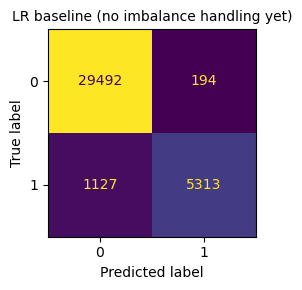

2026/04/11 22:14:30 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.
2026/04/11 22:14:30 WARNING mlflow.sklearn: Saving scikit-learn models in the pickle or cloudpickle format requires exercising caution because these formats rely on Python's object serialization mechanism, which can execute arbitrary code during deserialization. The recommended safe alternative is the 'skops' format. For more information, see: https://scikit-learn.org/stable/model_persistence.html


In [28]:
lr_baseline = LogisticRegression(max_iter=1000, random_state=42)

lr_base_metrics, lr_base_model = run_experiment(
    run_name = 'LR baseline (no imbalance handling yet)',
    model    = lr_baseline,
    X_tr     = X_train,
    y_tr     = y_train,
    params   = {'model': 'LogisticRegression', 'imbalance': 'none', 'max_iter': 1000},
    tags     = {'stage': 'baseline'},
)

## Data imbalance strategies
### SMOTE

In [29]:
X_smote, y_smote = SMOTE(random_state=42).fit_resample(X_train, y_train)
print(f'After SMOTE — class counts: {pd.Series(y_smote).value_counts().to_dict()}')

After SMOTE — class counts: {0: 89054, 1: 89054}


### Logistic regression after SMOTE

  
LR — SMOTE
  accuracy: 0.9394
  f1: 0.8408
  precision: 0.7909
  recall: 0.8974
  roc_auc: 0.9778

              precision    recall  f1-score   support

           0       0.98      0.95      0.96     29686
           1       0.79      0.90      0.84      6440

    accuracy                           0.94     36126
   macro avg       0.88      0.92      0.90     36126
weighted avg       0.94      0.94      0.94     36126



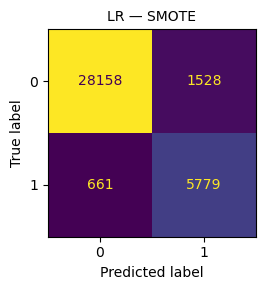

2026/04/11 22:14:55 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.
2026/04/11 22:14:55 WARNING mlflow.sklearn: Saving scikit-learn models in the pickle or cloudpickle format requires exercising caution because these formats rely on Python's object serialization mechanism, which can execute arbitrary code during deserialization. The recommended safe alternative is the 'skops' format. For more information, see: https://scikit-learn.org/stable/model_persistence.html


In [30]:
lr_smote_metrics, lr_smote_model = run_experiment(
    run_name = 'LR — SMOTE',
    model    = LogisticRegression(max_iter=1000, random_state=42),
    X_tr     = X_smote,
    y_tr     = y_smote,
    params   = {'model': 'LogisticRegression', 'imbalance': 'SMOTE'},
    tags     = {'stage': 'imbalance_strategy'},
)

### Logistic regression with class weights

  
LR — class_weight=balanced
  accuracy: 0.9402
  f1: 0.8425
  precision: 0.7939
  recall: 0.8974
  roc_auc: 0.9779

              precision    recall  f1-score   support

           0       0.98      0.95      0.96     29686
           1       0.79      0.90      0.84      6440

    accuracy                           0.94     36126
   macro avg       0.89      0.92      0.90     36126
weighted avg       0.94      0.94      0.94     36126



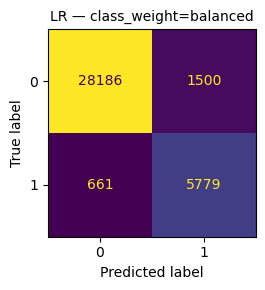

2026/04/11 22:15:04 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.
2026/04/11 22:15:04 WARNING mlflow.sklearn: Saving scikit-learn models in the pickle or cloudpickle format requires exercising caution because these formats rely on Python's object serialization mechanism, which can execute arbitrary code during deserialization. The recommended safe alternative is the 'skops' format. For more information, see: https://scikit-learn.org/stable/model_persistence.html


In [31]:
lr_cw_metrics, lr_cw_model = run_experiment(
    run_name = 'LR — class_weight=balanced',
    model    = LogisticRegression(max_iter=1000, class_weight='balanced', random_state=42),
    X_tr     = X_train,
    y_tr     = y_train,
    params   = {'model': 'LogisticRegression', 'imbalance': 'class_weight'},
    tags     = {'stage': 'imbalance_strategy'},
)

# Other Models

## with SMOTE